In [1]:
from __future__ import annotations

import anndata
import pandas as pd
import scanpy as sc
from matplotlib import pyplot as plt

In [2]:
# note that this collection of batches is already intersected on the genes
anndata = sc.read(
    "data/pancreas.h5ad",
    backup_url="https://www.dropbox.com/s/qj1jlm9w10wmt0u/pancreas.h5ad?dl=1",
)
anndata

/anaconda3/envs/bibola/lib/python3.11/site-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
/anaconda3/envs/bibola/lib/python3.11/site-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  return AnnData(**{


AnnData object with n_obs × n_vars = 14693 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [3]:
counts = anndata.obs["celltype"].value_counts()
counts.to_frame()

,count
celltype,
alpha,4214
beta,3354
ductal,1804
acinar,1368
not applicable,1154
delta,917
gamma,571
endothelial,289
activated_stellate,284


In [4]:
minority_classes = counts.index[-5:].tolist()  # get the minority classes
# actually subset
anndata = anndata[~anndata.obs["celltype"].isin(minority_classes)].copy()
# reorder according to abundance
anndata.obs["celltype"] = anndata.obs["celltype"].cat.reorder_categories(counts.index[:-5].tolist())
anndata.obs

,celltype,sample,n_genes,batch,n_counts,louvain
index,,,,,,
human1_lib1.final_cell_0001-0,acinar,Baron,3526,0,2.241100e+04,2
human1_lib1.final_cell_0002-0,acinar,Baron,4201,0,2.794900e+04,2
human1_lib1.final_cell_0003-0,acinar,Baron,2119,0,1.689200e+04,2
human1_lib1.final_cell_0004-0,acinar,Baron,2956,0,1.929900e+04,2
human1_lib1.final_cell_0005-0,acinar,Baron,2715,0,1.506700e+04,2
...,...,...,...,...,...,...
reads.29499-3,ductal,Wang,19950,3,1.056558e+06,10
reads.29500-3,ductal,Wang,19950,3,9.926309e+05,10
reads.29501-3,beta,Wang,19950,3,1.751338e+06,10


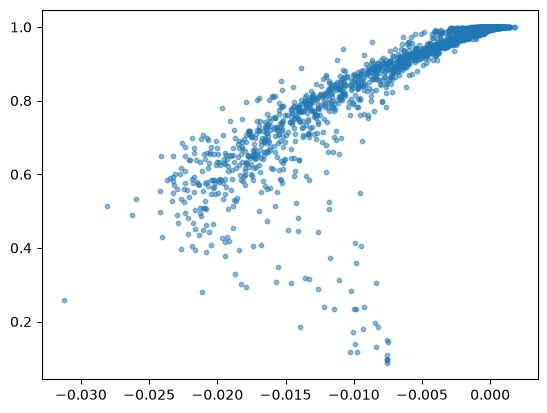

In [5]:
plt.scatter(
    anndata.X.mean(axis=0),
    anndata.X.std(axis=0),
    alpha=.5, s=10
)
plt.show()

In [6]:
sc.pp.pca(anndata)
sc.pp.neighbors(anndata)
sc.tl.umap(anndata)

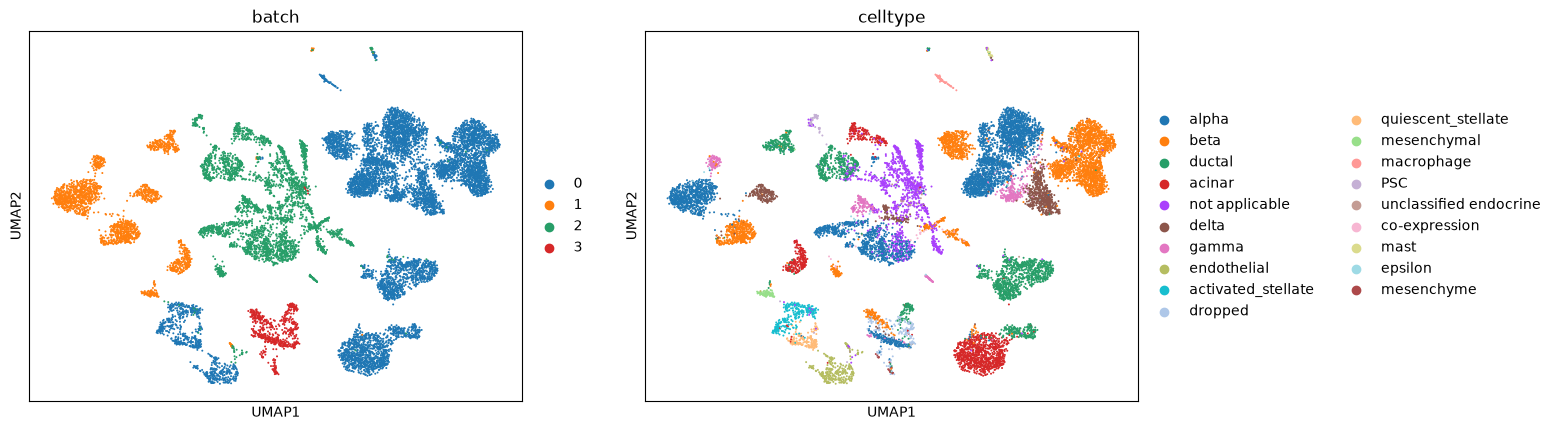

In [7]:
# original UMAP (without batch correction)
sc.pl.umap(anndata, color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)

In [8]:
import torch

from bibola.model import ChunkIntegration

In [9]:
batch_correction_model = ChunkIntegration(
    in_channels=anndata.obsm["X_pca"].shape[1],
    hidden_channels=[128,],
    out_channels=50,
    dropout=0.1,
    optimizer_kwargs={"lr": 1e-3}
)
batch_correction_model

ChunkIntegration(in_channels=50, hidden_channels=[128], out_channels=50, optimizer=Adam, not fitted)

In [10]:
batch_correction_model.fit(
    anndata.obsm["X_pca"], anndata.obs["batch"], epochs=10,
    print_every=1, k_inter=5, k_intra=100, norm=1,
    loss_weights={"abs_lisa_loss":1., "topology_loss":1., "knn_loss":1., "reconstruction_loss":1.},
    n_chunks=5, adaptive_loss_weights=True, adaptation_rate=1.
)

Epoch 1/10 - total_loss=-0.0520 (abs_lisa_loss=0.0353, topology_loss=-0.9106, knn_loss=-0.3355, reconstruction_loss=1.0027)
Epoch 2/10 - total_loss=-0.0920 (abs_lisa_loss=0.0262, topology_loss=-0.9151, knn_loss=-0.4546, reconstruction_loss=0.9754)
Epoch 3/10 - total_loss=-0.1118 (abs_lisa_loss=0.0223, topology_loss=-0.9047, knn_loss=-0.5433, reconstruction_loss=0.9539)
Epoch 4/10 - total_loss=-0.1277 (abs_lisa_loss=0.0186, topology_loss=-0.8957, knn_loss=-0.6063, reconstruction_loss=0.9359)
Epoch 5/10 - total_loss=-0.1390 (abs_lisa_loss=0.0171, topology_loss=-0.8866, knn_loss=-0.6490, reconstruction_loss=0.9189)
Epoch 6/10 - total_loss=-0.1504 (abs_lisa_loss=0.0156, topology_loss=-0.8827, knn_loss=-0.6767, reconstruction_loss=0.9011)
Epoch 7/10 - total_loss=-0.1608 (abs_lisa_loss=0.0159, topology_loss=-0.8836, knn_loss=-0.6907, reconstruction_loss=0.8821)
Epoch 8/10 - total_loss=-0.1719 (abs_lisa_loss=0.0148, topology_loss=-0.8823, knn_loss=-0.7042, reconstruction_loss=0.8609)
Epoch 9/

In [11]:
batch_correction_model.loss_history

loss                                              loss_weights  \
  abs_lisa_loss topology_loss  knn_loss reconstruction_loss abs_lisa_loss   
0      0.035350     -0.910616 -0.335528            1.002693      1.000000   
1      0.026161     -0.915129 -0.454553            0.975400      1.000000   
2      0.022320     -0.904676 -0.543327            0.953865      1.032100   
3      0.018641     -0.895749 -0.606260            0.935938      1.053529   
4      0.017130     -0.886589 -0.649029            0.918930      1.067379   
5      0.015639     -0.882720 -0.676719            0.901092      1.077539   
6      0.015858     -0.883555 -0.690740            0.882071      1.086011   
7      0.014757     -0.882258 -0.704167            0.860874      1.094623   
8      0.014058     -0.883909 -0.708813            0.837615      1.101961   
9      0.013630     -0.888875 -0.707758            0.812181      1.109208   

                                               
  topology_loss  knn_loss reconstruction_loss  
0      1.000000  1.000000            1.000000  
1      1.000000  1.000000            1.000000  
2      1.036970  0.917688            1.013242  
3      1.073690  0.856874            1.015908  
4      1.101568  0.816508            1.014545  
5      1.123937  0.790220            1.008304  
6      1.138856  0.775537            0.999596  
7      1.146678  0.770558            0.988141  
8      1.157135  0.766151            0.974753  
9      1.163635  0.768144            0.959013

In [12]:
anndata.obsm["X_corrected"] = batch_correction_model.transform(
    anndata.obsm["X_pca"], anndata.obs["batch"]
).numpy()

from sklearn.decomposition import PCA

# we apply PCA to reduce the collinearity after the batch correction.
pca_model = PCA(n_components=50)
anndata.obsm["X_corrected"] = pca_model.fit_transform(anndata.obsm["X_corrected"])
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors'
    obsm: 'X_pca', 'X_umap', 'X_corrected'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [13]:
sc.pp.neighbors(anndata, use_rep="X_corrected", key_added="neighbors_corrected")
sc.tl.umap(anndata, neighbors_key="neighbors_corrected", key_added="umap_corrected")
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors', 'neighbors_corrected', 'umap_corrected'
    obsm: 'X_pca', 'X_umap', 'X_corrected', 'umap_corrected'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities'

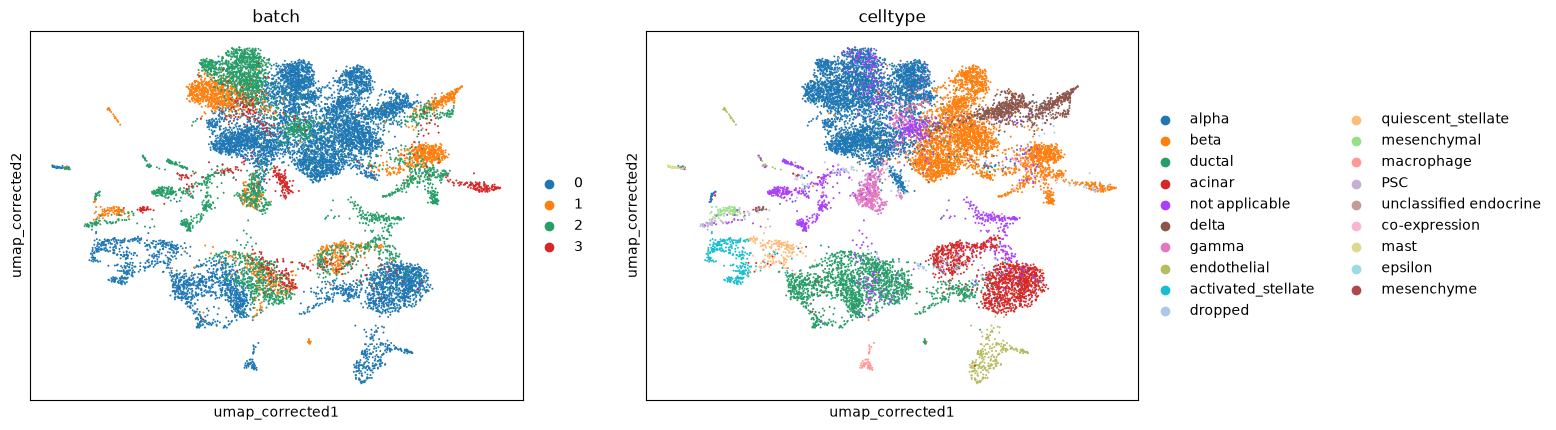

In [14]:
sc.pl.embedding(anndata, basis="umap_corrected", color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)
# UMAP after batch correction via bibola

In [ ]:
# reconstruct the PCA representation of the original data
anndata.obsm["X_pca_reconstructed"] = batch_correction_model.reconstruct(anndata.obsm["X_pca"], anndata.obs["batch"]).numpy()
sc.pp.neighbors(anndata, use_rep="X_pca_reconstructed", key_added="neighbors_reconstructed")
sc.tl.umap(anndata, neighbors_key="neighbors_reconstructed", key_added="umap_reconstructed")
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors', 'neighbors_corrected', 'umap_corrected', 'neighbors_reconstructed', 'umap_reconstructed'
    obsm: 'X_pca', 'X_umap', 'X_corrected', 'umap_corrected', 'X_pca_reconstructed', 'umap_reconstructed'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities', 'neighbors_reconstructed_distances', 'neighbors_reconstructed_connectivities'

In [18]:
# reconstruct the PCA representation of the original data siumating all cells belonging to batch 0
anndata.obsm["X_pca_simulated"] = batch_correction_model.reconstruct(anndata.obsm["X_pca"], anndata.obs["batch"], target_batch=["0",]).numpy()
sc.pp.neighbors(anndata, use_rep="X_pca_simulated", key_added="neighbors_simulated")
sc.tl.umap(anndata, neighbors_key="neighbors_simulated", key_added="umap_simulated")
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors', 'neighbors_corrected', 'umap_corrected', 'neighbors_reconstructed', 'umap_reconstructed', 'neighbors_simulated', 'umap_simulated'
    obsm: 'X_pca', 'X_umap', 'X_corrected', 'umap_corrected', 'X_pca_reconstructed', 'umap_reconstructed', 'X_pca_simulated', 'umap_simulated'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities', 'neighbors_reconstructed_distances', 'neighbors_reconstructed_connectivities', 'neighbors_simulated_distances', 'neighbors_simulated_connectivities'

index
human1_lib1.final_cell_0001-0    0
human1_lib1.final_cell_0002-0    0
human1_lib1.final_cell_0003-0    0
human1_lib1.final_cell_0004-0    0
human1_lib1.final_cell_0005-0    0
                                ..
reads.29499-3                    3
reads.29500-3                    3
reads.29501-3                    3
reads.29502-3                    3
reads.29503-3                    3
Name: batch, Length: 14662, dtype: category
Categories (4, object): ['0', '1', '2', '3']

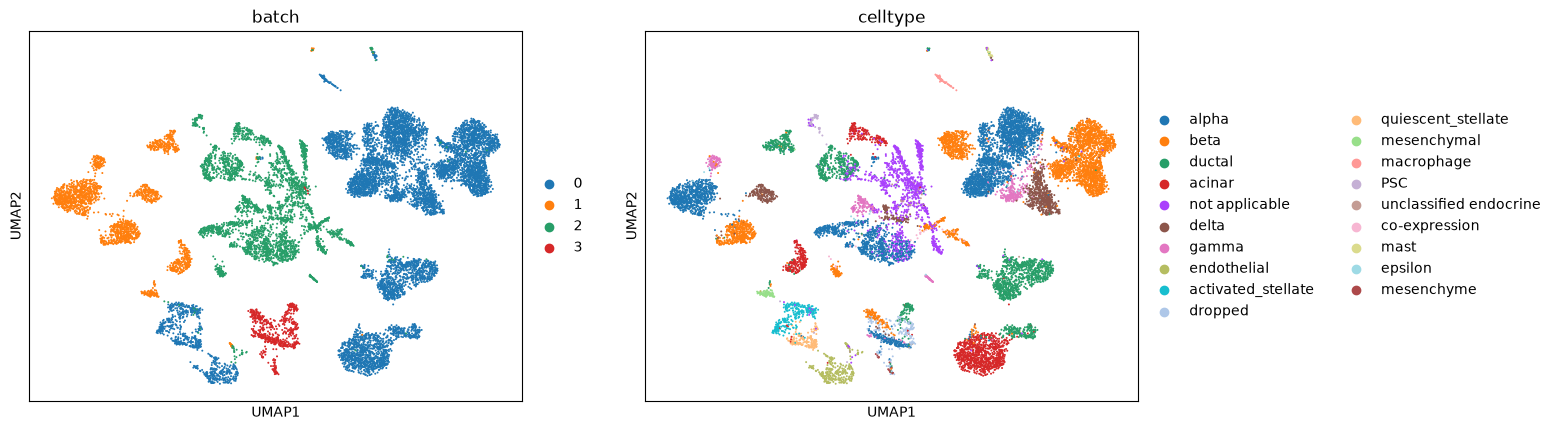

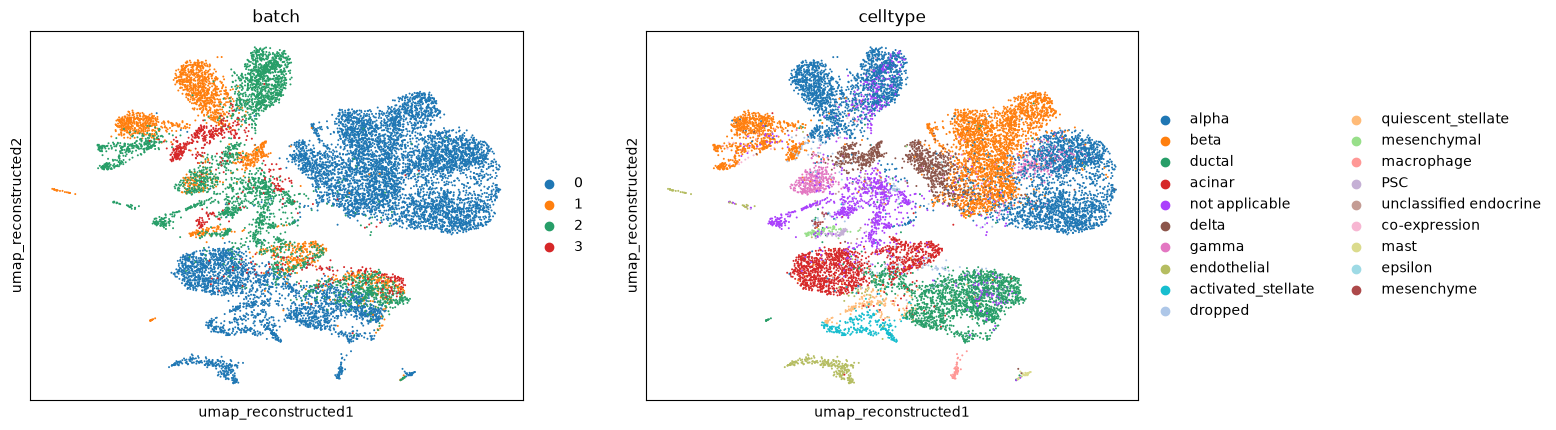

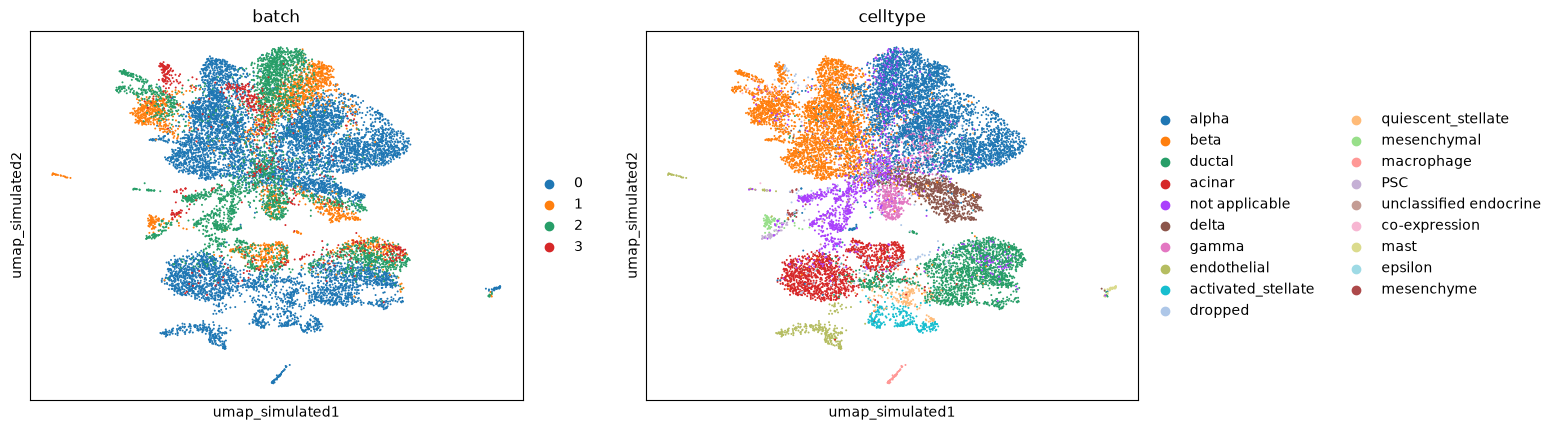

In [19]:
sc.pl.embedding(anndata, basis="umap", color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)
sc.pl.embedding(anndata, basis="umap_reconstructed", color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)
sc.pl.embedding(anndata, basis="umap_simulated", color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)
# UMAP after reconstruction (should be similar to the original UMAP)
# UMAP after simulation (should be batch-corrected)

In [20]:
from harmonypy import run_harmony

In [21]:
anndata.obsm["X_pca_harmony"] = run_harmony(anndata.obsm["X_pca"], anndata.obs, "batch").Z_corr
anndata.obsm["X_pca_harmony"]

2026-08-14 14:24:03,792 - harmonypy - INFO - Running Harmony
2026-08-14 14:24:03,792 - harmonypy - INFO -   Parameters:
2026-08-14 14:24:03,793 - harmonypy - INFO -     max_iter_harmony: 10
2026-08-14 14:24:03,793 - harmonypy - INFO -     max_iter_kmeans: 4
2026-08-14 14:24:03,793 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-08-14 14:24:03,794 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-08-14 14:24:03,794 - harmonypy - INFO -     nclust: 100
2026-08-14 14:24:03,794 - harmonypy - INFO -     block_size: 0.05
2026-08-14 14:24:03,795 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-08-14 14:24:03,796 - harmonypy - INFO -     theta: [2. 2. 2. 2.]
2026-08-14 14:24:03,796 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-08-14 14:24:03,797 - harmonypy - INFO -     verbose: True
2026-08-14 14:24:03,797 - harmonypy - INFO -     random_state: 0
2026-08-14 14:24:03,797 - harmonypy - INFO -   Data: 50 PCs × 14662 cells
2026-08-14 14:24:03,798 - harmonypy - INFO -

array([[  0.15425171,  -4.53972244,  -8.52065468, ...,  -0.38841876,
         -1.45698595,   0.08615991],
       [  3.89552402,  -4.51804066, -10.26223946, ...,  -1.12404025,
          0.90807426,   0.02703966],
       [ -3.71449828,  -4.54087257,  -6.43288279, ...,  -0.76113915,
          0.75945079,   0.08842079],
       ...,
       [  2.96661663,  10.92668152,   5.37792253, ...,   4.19615793,
          1.68354046,   0.28366753],
       [ 14.31705666,  -1.82588816, -12.1900053 , ...,   1.48150325,
          0.90651804,   1.02317023],
       [  3.00160837,  12.04156685,   4.41478348, ...,   0.0424562 ,
          0.6069088 ,   1.26845121]], shape=(14662, 50))

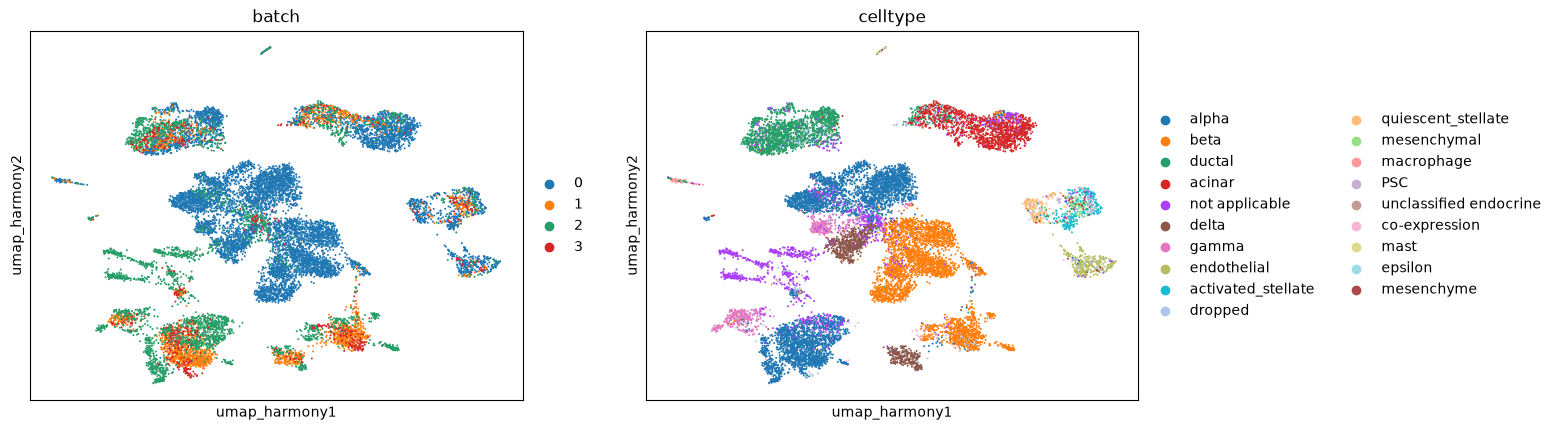

In [22]:
sc.pp.neighbors(anndata, use_rep="X_pca_harmony", key_added="neighbors_harmony")
sc.tl.umap(anndata, neighbors_key="neighbors_harmony", key_added="umap_harmony")
sc.pl.embedding(anndata, color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy, basis="umap_harmony")
# UMAP after batch correction via harmony

In [23]:
# We can even consider to run the bibola workflow starting from harmony correction, instead of PCA.
# This in order to have a warmer initializzation of the gradient, since the data is already well integrated and we just need to refine the integration at a local level..
# In this case, we will prioritize the spatial autocorrelation (LIBSA) loss since the batches are already "close" enough.

In [27]:
batch_correction_model = ChunkIntegration(
    in_channels=anndata.obsm["X_pca_harmony"].shape[1],
    hidden_channels=[128,],
    out_channels=50,
    dropout=0.1,
    optimizer_kwargs={"lr": 1e-3}
)
batch_correction_model

ChunkIntegration(in_channels=50, hidden_channels=[128], out_channels=50, optimizer=Adam, not fitted)

In [28]:
batch_correction_model.fit(
    anndata.obsm["X_pca_harmony"], anndata.obs["batch"], epochs=10,
    print_every=1, k_inter=5, k_intra=100, norm=1,
    loss_weights={"abs_lisa_loss":1, "topology_loss":1, "knn_loss": 1, "reconstruction_loss":1.},
    n_chunks=5, adaptive_loss_weights=True, adaptation_rate=1.
)

Epoch 1/10 - total_loss=-0.0270 (abs_lisa_loss=0.0333, topology_loss=-0.8760, knn_loss=-0.2671, reconstruction_loss=1.0016)
Epoch 2/10 - total_loss=-0.0673 (abs_lisa_loss=0.0225, topology_loss=-0.8954, knn_loss=-0.3658, reconstruction_loss=0.9695)
Epoch 3/10 - total_loss=-0.0942 (abs_lisa_loss=0.0166, topology_loss=-0.8973, knn_loss=-0.4566, reconstruction_loss=0.9438)
Epoch 4/10 - total_loss=-0.1127 (abs_lisa_loss=0.0136, topology_loss=-0.8883, knn_loss=-0.5287, reconstruction_loss=0.9219)
Epoch 5/10 - total_loss=-0.1286 (abs_lisa_loss=0.0128, topology_loss=-0.8822, knn_loss=-0.5823, reconstruction_loss=0.9020)
Epoch 6/10 - total_loss=-0.1419 (abs_lisa_loss=0.0114, topology_loss=-0.8768, knn_loss=-0.6226, reconstruction_loss=0.8822)
Epoch 7/10 - total_loss=-0.1541 (abs_lisa_loss=0.0116, topology_loss=-0.8767, knn_loss=-0.6466, reconstruction_loss=0.8616)
Epoch 8/10 - total_loss=-0.1672 (abs_lisa_loss=0.0107, topology_loss=-0.8778, knn_loss=-0.6679, reconstruction_loss=0.8393)
Epoch 9/

In [29]:
batch_correction_model.loss_history

loss                                              loss_weights  \
  abs_lisa_loss topology_loss  knn_loss reconstruction_loss abs_lisa_loss   
0      0.033330     -0.875997 -0.267061            1.001592      1.000000   
1      0.022465     -0.895395 -0.365803            0.969511      1.000000   
2      0.016555     -0.897338 -0.456604            0.943844      1.030640   
3      0.013589     -0.888286 -0.528723            0.921913      1.056027   
4      0.012793     -0.882160 -0.582290            0.902001      1.074190   
5      0.011431     -0.876797 -0.622608            0.882154      1.089397   
6      0.011607     -0.876703 -0.646622            0.861560      1.101064   
7      0.010740     -0.877790 -0.667942            0.839297      1.112074   
8      0.009534     -0.877049 -0.684311            0.816152      1.122473   
9      0.009442     -0.880287 -0.694220            0.791655      1.131144   

                                               
  topology_loss  knn_loss reconstruction_loss  
0      1.000000  1.000000            1.000000  
1      1.000000  1.000000            1.000000  
2      1.021750  0.939076            1.008534  
3      1.051095  0.880040            1.012838  
4      1.082061  0.833087            1.010662  
5      1.104981  0.800261            1.005361  
6      1.124337  0.777279            0.997320  
7      1.135487  0.766064            0.986375  
8      1.145852  0.757399            0.974277  
9      1.156955  0.751663            0.960238

In [30]:
anndata.obsm["X_corrected_after_harmony"] = batch_correction_model.transform(
    anndata.obsm["X_pca_harmony"], anndata.obs["batch"]
).numpy()

from sklearn.decomposition import PCA

pca_model = PCA(n_components=50)
anndata.obsm["X_corrected_after_harmony"] = pca_model.fit_transform(anndata.obsm["X_corrected_after_harmony"])
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors', 'neighbors_corrected', 'umap_corrected', 'neighbors_reconstructed', 'umap_reconstructed', 'neighbors_simulated', 'umap_simulated', 'neighbors_harmony', 'umap_harmony'
    obsm: 'X_pca', 'X_umap', 'X_corrected', 'umap_corrected', 'X_pca_reconstructed', 'umap_reconstructed', 'X_pca_simulated', 'umap_simulated', 'X_pca_harmony', 'umap_harmony', 'X_corrected_after_harmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities', 'neighbors_reconstructed_distances', 'neighbors_reconstructed_connectivities', 'neighbors_simulated_distances', 'neighbors_simulated_connectivities', 'neighbors_harmony_distances', 'neighbors_harmony_connectivities'

In [31]:
sc.pp.neighbors(anndata, use_rep="X_corrected_after_harmony", key_added="neighbors_corrected_after_harmony")
sc.tl.umap(anndata, neighbors_key="neighbors_corrected_after_harmony", key_added="umap_corrected_after_harmony")
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors', 'neighbors_corrected', 'umap_corrected', 'neighbors_reconstructed', 'umap_reconstructed', 'neighbors_simulated', 'umap_simulated', 'neighbors_harmony', 'umap_harmony', 'neighbors_corrected_after_harmony', 'umap_corrected_after_harmony'
    obsm: 'X_pca', 'X_umap', 'X_corrected', 'umap_corrected', 'X_pca_reconstructed', 'umap_reconstructed', 'X_pca_simulated', 'umap_simulated', 'X_pca_harmony', 'umap_harmony', 'X_corrected_after_harmony', 'umap_corrected_after_harmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities', 'neighbors_reconstructed_distances', 'neighbors_reconstructed_connectivities', 'neighbors_simulated_distances', 'nei

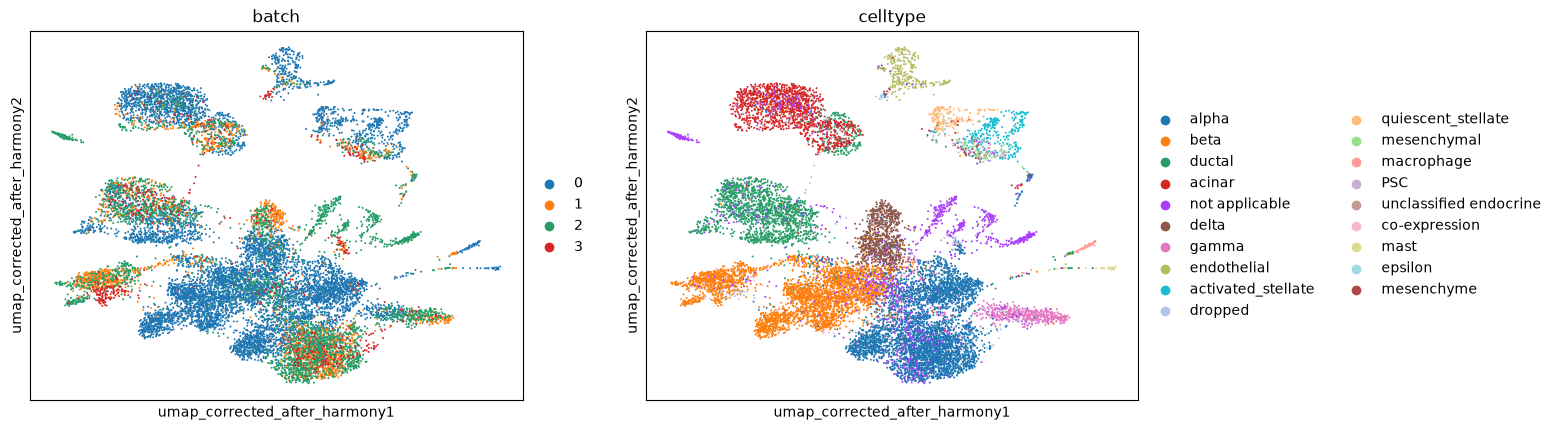

In [32]:
sc.pl.embedding(anndata, basis="umap_corrected_after_harmony", color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)
# UMAP after batch correction via bibola, starting from harmony
# we see an improvement in the integration of the batches, and a better separation of the cell types, compared to harmony alone.